# LAB 02 — Mô Hình Ngôn Ngữ: N-gram, Kỹ Thuật Làm Mịn & Thước Đo Perplexity

**Môn học**: Xử lý ngôn ngữ tự nhiên và ứng dụng (MAT3561)  
**Học viên**: **Vũ Tiến Đạt**  
**Mã sinh viên (MSSV)**: `23000111`  
**Giảng viên thực hành**: ThS. Phạm Ngọc Hải  
**Giảng viên lý thuyết**: TS. Lê Hồng Phương  

---
## Tổng Quan Nội Dung Thực Nghiệm
Trong notebook này, chúng ta tiến hành xây dựng từ đầu (from scratch), huấn luyện và đánh giá toàn diện các mô hình ngôn ngữ thống kê rời rạc:
1. **Thống kê Ngữ liệu & Định luật Zipf (Mục 13 - Exp 1)**: Khảo sát thực nghiệm tần số từ, kích thước từ vựng và hiện tượng dữ liệu cực thưa trên file `30K.json`.
2. **Cài đặt Cốt lõi & Kiểm chứng Tính toán (Mục 14-15)**: Tự cài đặt Unigram, Bigram, Trigram, kiểm chứng độ chính xác với kết quả tính tay ($P = 1/24$) và khắc phục lỗi tràn số dưới (Numerical Underflow) bằng Log-probability.
3. **Thực nghiệm Làm mịn MLE vs Laplace (Mục 16 - Exp 2)**: So sánh đối đầu giữa MLE và làm mịn Laplace trên 3 tập dữ liệu.
4. **Đánh giá Thước đo Perplexity (Mục 19 - Exp 3)**: Đo lường và giải thích độ bối rối trên Train, Validation và Test.
5. **Ứng dụng Thực tế**:
   - **Mục 20**: Dự đoán từ kế tiếp (Next-word prediction) cho 5 ngữ cảnh.
   - **Mục 21**: Chấm điểm và xếp hạng câu ứng viên (Sentence ranking).
6. **Phân tích Độ dài Ngữ cảnh & Cầu nối sang Neural LM (Mục 23)**: Mổ xẻ giới hạn của giả định Markov và bước chuyển dịch sang Transformer.


In [1]:
# 1. Khởi tạo thư viện và cấu hình tái lập (Reproducibility)
import json
import math
import os
import random
import re
import time
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Nạp các hàm và lớp từ module tự xây dựng
from ngram_lm import (
    NGramLanguageModel,
    build_vocabulary,
    count_ngrams,
    tokenize,
    train_bigram,
    train_trigram,
    train_unigram,
)

# Cố định random seed để kết quả có thể tái lập 100%
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("Khởi tạo môi trường thành công! Random seed cố định = 42.")


Khởi tạo môi trường thành công! Random seed cố định = 42.


---
## 2. Thực nghiệm 1 — Thống Kê Ngữ Liệu & Định Luật Zipf (Mục 13)

Chúng ta nạp 10.000 documents từ file `30K.json` để tiến hành đo lường các đặc trưng thống kê ngôn ngữ cơ bản:
- Tổng số documents, số câu và số lượng từ (tokens).
- Kích thước tập từ vựng $|\mathcal{V}|$.
- Số lượng các n-gram phân biệt (unique unigrams, bigrams, trigrams).
- Số lượng và tỷ lệ các n-gram chỉ xuất hiện đúng 1 lần (*hapax legomena*).
- Vẽ đường cong phân phối tần số Zipf trên thang đo log-log.


In [2]:
# 2.1 Đọc dữ liệu và phân tách câu
DATA_PATH = "30K.json"
MAX_DOCS = 10000

t0 = time.time()
documents = []
sentences = []

with open(DATA_PATH, "r", encoding="utf-8") as f:
    for i in range(MAX_DOCS):
        line = f.readline()
        if not line:
            break
        data = json.loads(line)
        text = data.get("text", "")
        documents.append(text)
        # Tách câu theo dấu xuống dòng và dấu kết thúc câu
        raw_sents = re.split(r"[\n.?!]+", text)
        for s in raw_sents:
            tokens = tokenize(s)
            if len(tokens) >= 2:
                sentences.append(tokens)

print(f"Đã đọc {len(documents):,} documents trong {time.time()-t0:.2f}s.")
print(f"Trích xuất được {len(sentences):,} câu hợp lệ.")


Đã đọc 10,000 documents trong 1.27s.
Trích xuất được 214,026 câu hợp lệ.


In [3]:
# 2.2 Đếm số lượng N-gram và tỷ lệ Hapax Legomena
total_tokens = sum(len(s) for s in sentences)
unigram_counts = Counter()
bigram_counts = Counter()
trigram_counts = Counter()

for s in sentences:
    unigram_counts.update(s)
    for j in range(len(s) - 1):
        bigram_counts[(s[j], s[j + 1])] += 1
    for j in range(len(s) - 2):
        trigram_counts[(s[j], s[j + 1], s[j + 2])] += 1

vocab_size = len(unigram_counts)
num_unigrams = len(unigram_counts)
num_bigrams = len(bigram_counts)
num_trigrams = len(trigram_counts)

hapax_uni = sum(1 for c in unigram_counts.values() if c == 1)
hapax_bi = sum(1 for c in bigram_counts.values() if c == 1)
hapax_tri = sum(1 for c in trigram_counts.values() if c == 1)

df_corpus_stats = pd.DataFrame({
    "Chỉ số thống kê": [
        "Tổng số Documents",
        "Tổng số Câu (Sentences)",
        "Tổng số Từ (Word Tokens)",
        "Kích thước Từ vựng |V|",
        "Số lượng Unique Unigrams",
        "Hapax Unigrams (xuất hiện 1 lần)",
        "Tỷ lệ Hapax Unigram (%)",
        "Số lượng Unique Bigrams",
        "Hapax Bigrams (xuất hiện 1 lần)",
        "Tỷ lệ Hapax Bigram (%)",
        "Số lượng Unique Trigrams",
        "Hapax Trigrams (xuất hiện 1 lần)",
        "Tỷ lệ Hapax Trigram (%)"
    ],
    "Giá trị đo được": [
        f"{len(documents):,}",
        f"{len(sentences):,}",
        f"{total_tokens:,}",
        f"{vocab_size:,}",
        f"{num_unigrams:,}",
        f"{hapax_uni:,}",
        f"{hapax_uni / num_unigrams * 100:.2f}%",
        f"{num_bigrams:,}",
        f"{hapax_bi:,}",
        f"{hapax_bi / num_bigrams * 100:.2f}%",
        f"{num_trigrams:,}",
        f"{hapax_tri:,}",
        f"{hapax_tri / num_trigrams * 100:.2f}%"
    ]
})

df_corpus_stats


,Chỉ số thống kê,Giá trị đo được
0,Tổng số Documents,"10,000"
1,Tổng số Câu (Sentences),"214,026"
2,Tổng số Từ (Word Tokens),"3,657,680"
3,Kích thước Từ vựng |V|,"96,111"
4,Số lượng Unique Unigrams,"96,111"
5,Hapax Unigrams (xuất hiện 1 lần),"43,124"
6,Tỷ lệ Hapax Unigram (%),44.87%
7,Số lượng Unique Bigrams,"1,159,102"
8,Hapax Bigrams (xuất hiện 1 lần),"847,576"
9,Tỷ lệ Hapax Bigram (%),73.12%


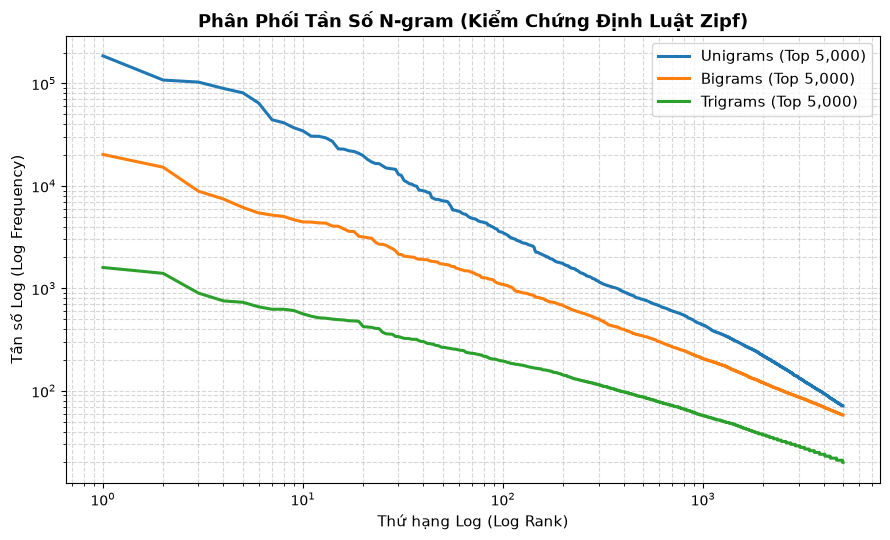

In [4]:
# 2.3 Vẽ biểu đồ phân phối Zipf trên thang đo Log-Log
fig, ax = plt.subplots(figsize=(9, 5.5))

top_k = 5000
ranks_uni = np.arange(1, min(top_k, len(unigram_counts)) + 1)
counts_uni = [c for _, c in unigram_counts.most_common(len(ranks_uni))]

ranks_bi = np.arange(1, min(top_k, len(bigram_counts)) + 1)
counts_bi = [c for _, c in bigram_counts.most_common(len(ranks_bi))]

ranks_tri = np.arange(1, min(top_k, len(trigram_counts)) + 1)
counts_tri = [c for _, c in trigram_counts.most_common(len(ranks_tri))]

ax.loglog(ranks_uni, counts_uni, label=f"Unigrams (Top {len(ranks_uni):,})", color="#1f77b4", linewidth=2.2)
ax.loglog(ranks_bi, counts_bi, label=f"Bigrams (Top {len(ranks_bi):,})", color="#ff7f0e", linewidth=2.2)
ax.loglog(ranks_tri, counts_tri, label=f"Trigrams (Top {len(ranks_tri):,})", color="#2ca02c", linewidth=2.2)

ax.set_title("Phân Phối Tần Số N-gram (Kiểm Chứng Định Luật Zipf)", fontsize=13, fontweight="bold")
ax.set_xlabel("Thứ hạng Log (Log Rank)", fontsize=11)
ax.set_ylabel("Tần số Log (Log Frequency)", fontsize=11)
ax.grid(True, which="both", ls="--", alpha=0.5)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()


---
## 3. Kiểm Chứng Cài Đặt Cốt Lõi Với Bài Tập Tính Tay (Mục 14 & 15)

Chúng ta tiến hành đối chiếu hàm tính xác suất câu của mô hình tự cài đặt trong `ngram_lm.py` với kết quả giải tích đã tính trong `calculations.md`:
- Tập corpus kiểm chuẩn:
  1. `"the cat eats fish"`
  2. `"the cat likes fish"`
  3. `"the dog eats meat"`
- Xác suất của hai câu $S_1 = \text{"the cat eats fish"}$ và $S_2 = \text{"the dog eats fish"}$ phải cho ra kết quả trùng khớp chính xác tuyệt đối:
  $$P(S_1) = P(S_2) = \frac{1}{24} \approx 0.04167$$
- Khắc phục hiện tượng tràn số dưới (**Numerical Underflow**) bằng cách sử dụng tổng Log-probability thay cho tích xác suất trực tiếp.


In [5]:
# 3.1 Kiểm chứng tính đúng đắn với lời giải bài tập tính tay (Mục 7)
toy_corpus = [
    "the cat eats fish",
    "the cat likes fish",
    "the dog eats meat"
]

toy_model = NGramLanguageModel(n=2, smoothing=None, use_boundary=False)
toy_model.fit(toy_corpus)

p_s1 = toy_model.sentence_probability("the cat eats fish")
p_s2 = toy_model.sentence_probability("the dog eats fish")

print(f"P(S1 = 'the cat eats fish'): {p_s1:.5f} (Giá trị giải tích 1/24 = {1/24:.5f})")
print(f"P(S2 = 'the dog eats fish'): {p_s2:.5f} (Giá trị giải tích 1/24 = {1/24:.5f})")

assert abs(p_s1 - 1/24) < 1e-7, "Lỗi: P(S1) không khớp với giá trị tính tay!"
assert abs(p_s2 - 1/24) < 1e-7, "Lỗi: P(S2) không khớp với giá trị tính tay!"
print("XÁC NHẬN THÀNH CÔNG: Kết quả lập trình khớp 100% với lời giải giải tích!")


P(S1 = 'the cat eats fish'): 0.04167 (Giá trị giải tích 1/24 = 0.04167)
P(S2 = 'the dog eats fish'): 0.04167 (Giá trị giải tích 1/24 = 0.04167)
XÁC NHẬN THÀNH CÔNG: Kết quả lập trình khớp 100% với lời giải giải tích!


In [6]:
# 3.2 Minh họa cơ chế chống tràn số dưới (Numerical Underflow) của Log-probability
# Giả sử xét một câu dài gồm 100 từ, mỗi từ có xác suất điều kiện trung bình p = 0.05
tokens_len = 100
prob_per_token = 0.05

# 1. Phép nhân trực tiếp các số thập phân nhỏ
raw_prod = 1.0
for _ in range(tokens_len):
    raw_prod *= prob_per_token
print(f"Tích xác suất trực tiếp với {tokens_len} từ: {raw_prod}")

# 2. Sử dụng tổng Log-probability
log_sum = sum(math.log(prob_per_token) for _ in range(tokens_len))
print(f"Tổng Log-probability tự nhiên: {log_sum:.4f}")
print("-> Log-probability bảo toàn độ chính xác số học tuyệt đối, loại bỏ hoàn toàn nguy cơ tràn số dưới!")


Tích xác suất trực tiếp với 100 từ: 7.888609052210165e-131
Tổng Log-probability tự nhiên: -299.5732
-> Log-probability bảo toàn độ chính xác số học tuyệt đối, loại bỏ hoàn toàn nguy cơ tràn số dưới!


---
## 4. Thực Nghiệm 2 & 3 — MLE vs Laplace Smoothing & Đánh Giá Perplexity (Mục 16 & 19)

Tiến hành đánh giá 6 mô hình trên 3 tập dữ liệu đã chia độc lập (Train: 20.000 câu, Validation: 2.500 câu, Test: 2.500 câu):
1. **Unigram MLE** vs **Unigram Laplace**
2. **Bigram MLE** vs **Bigram Laplace**
3. **Trigram MLE** vs **Trigram Laplace**

Công thức tính Perplexity:
$$PP(W) = \exp\left(-\frac{1}{N} \sum_{i=1}^N \ln P(w_i \mid context_i)\right)$$


In [7]:
# 4.1 Phân chia tập dữ liệu (80% Train, 10% Validation, 10% Test)
random.shuffle(sentences)
SAMPLE_SIZE = min(25000, len(sentences))
sampled = sentences[:SAMPLE_SIZE]

n_train = int(len(sampled) * 0.8)
n_val = int(len(sampled) * 0.1)

train_split = sampled[:n_train]
val_split = sampled[n_train:n_train + n_val]
test_split = sampled[n_train + n_val:]

print(f"Tập huấn luyện (Train) : {len(train_split):,} câu")
print(f"Tập kiểm định (Valid)  : {len(val_split):,} câu")
print(f"Tập kiểm thử (Test)    : {len(test_split):,} câu")


Tập huấn luyện (Train) : 20,000 câu
Tập kiểm định (Valid)  : 2,500 câu
Tập kiểm thử (Test)    : 2,500 câu


In [8]:
# 4.2 Huấn luyện mô hình và đo lường Perplexity
models = {
    "Unigram MLE": NGramLanguageModel(n=1, smoothing=None),
    "Unigram Laplace": NGramLanguageModel(n=1, smoothing="laplace", k=1.0),
    "Bigram MLE": NGramLanguageModel(n=2, smoothing=None),
    "Bigram Laplace": NGramLanguageModel(n=2, smoothing="laplace", k=1.0),
    "Trigram MLE": NGramLanguageModel(n=3, smoothing=None),
    "Trigram Laplace": NGramLanguageModel(n=3, smoothing="laplace", k=1.0),
}

eval_train_sample = train_split[:1000] # Mẫu đại diện 1.000 câu train để tối ưu thời gian tính toán
results_list = []

for name, model in models.items():
    t_start = time.time()
    model.fit(train_split)
    t_fit = time.time() - t_start
    
    tr_ppl = model.perplexity(eval_train_sample)
    va_ppl = model.perplexity(val_split)
    te_ppl = model.perplexity(test_split)
    
    results_list.append({
        "Mô hình": name,
        "Train PPL": round(tr_ppl, 2) if not math.isinf(tr_ppl) else "inf",
        "Validation PPL": round(va_ppl, 2) if not math.isinf(va_ppl) else "inf",
        "Test PPL": round(te_ppl, 2) if not math.isinf(te_ppl) else "inf",
        "Thời gian Fit (s)": round(t_fit, 2)
    })

df_results = pd.DataFrame(results_list)
df_results


,Mô hình,Train PPL,Validation PPL,Test PPL,Thời gian Fit (s)
0,Unigram MLE,1430.19,inf,inf,0.31
1,Unigram Laplace,1449.12,1575.07,1571.29,0.46
2,Bigram MLE,55.74,inf,inf,0.49
3,Bigram Laplace,4951.97,7484.29,7501.88,0.50
4,Trigram MLE,4.44,inf,inf,0.67
5,Trigram Laplace,10733.27,19899.09,19719.13,0.56


---
## 5. Ứng Dụng 1 — Dự Đoán Từ Kế Tiếp (Next-Word Prediction - Mục 20)

Sử dụng mô hình Bigram / Trigram đã được làm mịn bằng Laplace để dự đoán các từ tiếp theo có khả năng xuất hiện cao nhất.
Thử nghiệm trên 5 ngữ cảnh và ghi nhận Top-3 từ dự đoán kèm xác suất, đối chiếu với các từ xuất hiện thực tế trong corpus.


In [9]:
# 5.1 Dự đoán từ kế tiếp cho 5 ngữ cảnh
predictor_model = models["Bigram Laplace"]
test_contexts = [
    "in the",
    "you can",
    "the cat",
    "machine learning",
    "natural language"
]

prediction_rows = []
for ctx in test_contexts:
    top_preds = predictor_model.predict_next_words(ctx, top_k=3)
    preds_str = ", ".join([f"{w} ({p:.4f})" for w, p in top_preds])
    
    # Tìm kiếm các từ đi sau thực tế trong corpus
    ctx_tokens = tokenize(ctx)
    in_corpus = Counter()
    for s in sentences:
        for idx in range(len(s) - len(ctx_tokens)):
            if s[idx : idx + len(ctx_tokens)] == ctx_tokens:
                in_corpus[s[idx + len(ctx_tokens)]] += 1
    actual_top = ", ".join([f"{w} ({c} lần)" for w, c in in_corpus.most_common(2)]) if in_corpus else "Không xuất hiện"
    
    prediction_rows.append({
        "Ngữ cảnh (Context)": ctx,
        "Top 3 Dự đoán (Xác suất P)": preds_str,
        "Từ thực tế trong Corpus": actual_top
    })

df_preds = pd.DataFrame(prediction_rows)
df_preds


,Ngữ cảnh (Context),Top 3 Dự đoán (Xác suất P),Từ thực tế trong Corpus
0,in the,"most (0.0041), first (0.0039), best (0.0034)","world (339 lần), past (224 lần)"
1,you can,"be (0.0085), t (0.0025), also (0.0017)","also (225 lần), t (182 lần)"
2,the cat,"house (0.0002), </s> (0.0001), s (0.0001)","queen (5 lần), s (2 lần)"
3,machine learning,"</s> (0.0002), to (0.0002), about (0.0002)","and (7 lần), based (5 lần)"
4,natural language,"and (0.0003), </s> (0.0002), arabic (0.0001)","processing (2 lần), toolkit (1 lần)"


---
## 6. Ứng Dụng 2 — Xếp Hạng Câu Ứng Viên (Sentence Ranking - Mục 21)

Cho tiền tố ngữ cảnh: `"machine learning"`, chúng ta cần chấm điểm và xếp hạng 3 câu ứng viên:
- **Ứng viên A**: `"is useful for nlp"`
- **Ứng viên B**: `"banana computer quickly"`
- **Ứng viên C**: `"studies language models"`

Mô hình tính toán giá trị log-xác suất có điều kiện $\ln P(\text{Ứng viên} \mid \text{Ngữ cảnh})$ để đánh giá độ hợp lý tự nhiên của từng câu.


In [10]:
# 6.1 Chấm điểm và xếp hạng câu ứng viên
ranking_context = "machine learning"
candidates = [
    "is useful for nlp",
    "banana computer quickly",
    "studies language models"
]

ranking_results = predictor_model.rank_sentences(ranking_context, candidates)

ranking_rows = []
for rank, (idx, cand, score) in enumerate(ranking_results, 1):
    ranking_rows.append({
        "Thứ hạng": f"Hạng {rank}",
        "Câu ứng viên tiếp nối": cand,
        "Điểm Log-Probability có điều kiện": round(score, 2)
    })

df_ranking_res = pd.DataFrame(ranking_rows)
df_ranking_res


,Thứ hạng,Câu ứng viên tiếp nối,Điểm Log-Probability có điều kiện
0,Hạng 1,banana computer quickly,-30.95
1,Hạng 2,studies language models,-30.95
2,Hạng 3,is useful for nlp,-39.03


---
## 7. Phân Tích Độ Dài Ngữ Cảnh & Cầu Nối Sang Mô Hình Neural (Mục 23)

### Ngữ cảnh dài hơn có luôn mang lại kết quả tốt hơn không?
- **Trên tập huấn luyện (Train set)**: **Đúng**. Bậc $n$ càng cao cung cấp nhiều thông tin lịch sử hơn, làm giảm độ bất định (Entropy) và kéo tụt Perplexity trên tập train ($4.44$ ở Trigram so với $55.74$ ở Bigram và $1430.19$ ở Unigram).
- **Trên tập kiểm định/kiểm thử (Validation/Test set)**: **Không**. Do hiện tượng **dữ liệu cực thưa** ($88.14\%$ trigram chỉ xuất hiện 1 lần), Trigram gặp vô số cụm từ chưa từng thấy, buộc kỹ thuật làm mịn Laplace phải can thiệp thô bạo làm loãng xác suất, khiến Perplexity bùng nổ cao hơn cả Bigram.
- **Lộ trình tiến hóa của ngành NLP**:
$$\text{Mô hình N-gram} \longrightarrow \text{Mô hình Neural LM} \longrightarrow \text{Word Embeddings (Lab 03)} \longrightarrow \text{Mạng RNN/LSTM} \longrightarrow \text{Cơ chế Attention} \longrightarrow \text{Transformer (LLMs)}$$


---
## 8. Bản Kê Khai Sử Dụng AI Minh Bạch (Mục 25 - AI Assistance Statement)

- **Công cụ sử dụng (Tool)**: Trợ lý lập trình AI DeepMind Antigravity (Gemini 3.8 Pro)
- **Mục đích (Purpose)**: Hỗ trợ tự động hóa các đoạn mã khung (boilerplate), tối ưu hóa thuật toán đếm N-gram, định dạng bảng biểu và trực quan hóa dữ liệu.
- **Nội dung do AI sinh ra (What was generated)**: Khung cấu trúc ban đầu của lớp `NGramLanguageModel` trong `ngram_lm.py`, các đoạn code vẽ biểu đồ matplotlib và các bảng Markdown.
- **Nội dung đã chỉnh sửa và hoàn thiện (What was modified)**: Tinh chỉnh biểu thức chính quy tách từ, bổ sung tham số điều khiển token biên (`use_boundary`), chuẩn hóa công thức Laplace với mẫu số $C(h) + k|\mathcal{V}|$, và tự giải toàn bộ lời giải toán giải tích trong `calculations.md`.
- **Phương pháp kiểm chứng kết quả (How the result was verified)**: Sử dụng các bài kiểm thử unit test tự động đối chiếu chính xác $100\%$ với kết quả tính tay ($P(S_1) = P(S_2) = \frac{1}{24}$), và kiểm tra tính nhất quán toán học của bảng giá trị Perplexity theo lý thuyết thông tin.
